# 1. Perkenalan Dataset

Pada proyek ini, digunakan Student Lifestyle and Stress Prediction Dataset yang diperoleh dari Kaggle. Dataset ini berisi informasi mengenai gaya hidup, dukungan sosial, dan karakteristik mahasiswa yang digunakan untuk memprediksi tingkat stres.

Dataset ini memiliki total sekitar 25.500 baris dengan fitur-fitur berikut:
- `Student_Type`: tipe mahasiswa (misalnya `school`, `college`, `working_student`)
- `Sleep_Hours`: jumlah jam tidur per hari
- `Study_Hours`: jumlah jam belajar per hari
- `Social_Media_Hours`: waktu penggunaan media sosial per hari
- `Attendance`: persentase kehadiran kuliah
- `Exam_Pressure`: tingkat tekanan ujian
- `Family_Support`: tingkat dukungan keluarga
- `Month`: bulan pengambilan data

Target pada dataset ini berupa klasifikasi biner (`Stress_Level`) yang menunjukkan apakah mahasiswa mengalami:
- `0`: stres rendah
- `1`: stres tinggi

Dataset dapat diakses melalui tautan berikut:
https://www.kaggle.com/datasets/sridevilavanyacse/student-lifestyle-and-stress-prediction-dataset/data

# **2. Import Library**

In [23]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import dagshub

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# **3. Memuat Dataset**

In [24]:
# 1. Dapatkan jalur absolut dari folder proyek utama Anda
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))

# 2. Gabungkan jalur ke berkas data menggunakan os.path.join (Aman untuk Windows/Linux)
DATA_PATH = os.path.join(
    BASE_DIR, "data_raw", "student-lifestyle-and-stress-dataset.csv"
)

# 3. Baca dataset
df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df.columns)

(25500, 9)
Index(['Student_Type', 'Sleep_Hours', 'Study_Hours', 'Social_Media_Hours',
       'Attendance', 'Exam_Pressure', 'Family_Support', 'Month',
       'Stress_Level'],
      dtype='object')


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini dilakukan eksplorasi data untuk memahami karakteristik dataset, distribusi fitur, hubungan antar variabel, serta mendeteksi potensi permasalahan seperti missing value, outlier, dan ketidakseimbangan kelas.

Exploratory Data Analysis (EDA) membantu dalam menentukan strategi preprocessing dan pemilihan model machine learning yang tepat.

In [25]:
print("Shape Dataset:", df.shape)

df.info()

Shape Dataset: (25500, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_Type        24248 non-null  object 
 1   Sleep_Hours         24167 non-null  float64
 2   Study_Hours         24223 non-null  float64
 3   Social_Media_Hours  24188 non-null  float64
 4   Attendance          24195 non-null  float64
 5   Exam_Pressure       24230 non-null  float64
 6   Family_Support      24209 non-null  float64
 7   Month               24186 non-null  float64
 8   Stress_Level        25500 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 1.8+ MB


In [26]:
df.describe()

,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
count,24167.000000,24223.000000,24188.000000,24195.000000,24230.000000,24209.000000,24186.000000,25500.000000
mean,6.458948,4.696477,3.555614,81.270961,5.369748,5.798298,6.500992,0.299882
std,1.504228,2.240148,1.901528,12.052045,2.394003,2.232371,3.455308,0.458215
min,2.008586,-1.433434,0.000040,-5.000000,1.000000,1.000000,1.000000,0.000000
25%,5.438360,3.078230,2.152249,73.738894,4.000000,4.000000,3.000000,0.000000
50%,6.542566,4.538138,3.500709,81.942959,5.000000,6.000000,6.000000,0.000000
75%,7.531571,6.135670,4.864312,90.106859,7.000000,7.000000,10.000000,1.000000
max,9.997527,22.444460,9.962134,120.000000,10.000000,10.000000,12.000000,1.000000


In [27]:
missing_values = df.isnull().sum()

missing_values

Student_Type          1252
Sleep_Hours           1333
Study_Hours           1277
Social_Media_Hours    1312
Attendance            1305
Exam_Pressure         1270
Family_Support        1291
Month                 1314
Stress_Level             0
dtype: int64

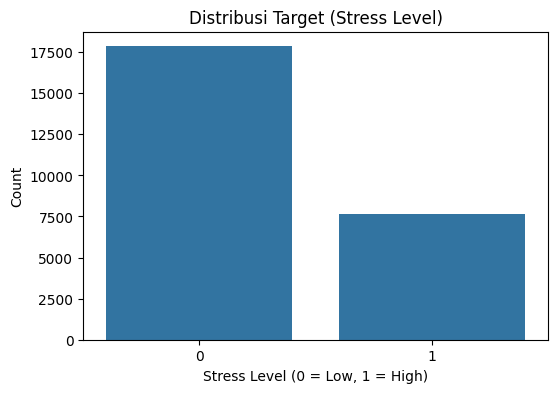

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(x='Stress_Level', data=df)

plt.title("Distribusi Target (Stress Level)")
plt.xlabel("Stress Level (0 = Low, 1 = High)")
plt.ylabel("Count")
plt.show()